# Instituto Politecnico Nacional
## Centro de Investigacion en computo
### departamento de diplomado y eextencion profesional


Profesor: Alan Badillo Salas

Alumno: Gonzalez Maldonado Salvador

Mayo 2025.ciudad de México.


## PROYECTO FINAL

#INTRODUCCION

en esta practica de REDES NEURONALES lo que se espera que se haga es permitir el entrenamiento de un model de visualizacion.
ya que estas se pueden establecer diferentes capas como sera la de entrada ,capas intermedias que son opccionales y una capa de salida  que se llamarian ("capas densas")

para eso se llevara acabo el desarrollo de una red Nueronal de las cuales se debe de considerar un tamaño de lote(Batch Size) y el numero de iteraciones o epocas de entrenamiento (Epochs).

en este proyecto veremos los que seria un modelo que nos aude  a predecir los accidentes de automoviles con respecto a la edad

primero importamos las libreria que vamos a neseitar como pandas ,numpy y matplot.pyplot

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url=("https://github.com/dragonnomada/ipn-cic-pycien-abril-2025/raw/refs/heads/main/datasets/atus_anual_1997.csv")
student=pd.read_csv(url)
student.sample(12)
student['SEXO'] = student['SEXO'].str.upper().map({'HOMBRE': 1, 'MUJER': 0})


despues de eso haremos un desgolse de todas las variables en base a la tabla para poder manjejar mejor la informacion

In [46]:

x1=student['ID_ENTIDAD']
x2=student['ID_DIA']
x3=student['MES']
x4=student['ANIO']
x5=student['ID_EDAD']
x6=student['CONDHERIDO']
x7=student['CONDMUERTO']
x8=student['OTROHERIDO']
x9=student['OTROMUERTO']
x10=student['CICLMUERTO']
x11=student['PEATMUERTO']
x12=student['NEMUERTO']
x13=student['SEXO']
x14=student['AUTOMOVIL']

despues de eso lo que se hara sera que la informacion se agrupara en un arrray para tener mejor forma de como evaluar la infirmacion que seria mes,edad,condherido y automovil

In [53]:
import numpy as np
X=np.array([x3,x5,x6,x14]).T
Y=x7

# Crear el vector Y (la variable objetivo)
X.shape,Y.shape

((248114, 4), (248114,))

despues de eso lo que se hara es importar desde sklearn.model el train_test_split  y se enntrenara con un tamaño de 0.8

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.8)

X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((198491, 4), (49623, 4), (198491,), (49623,))

importamos desde keras el sequential
y asi sucesivamente desde keras.layers importamos Dense,Input
 ,desde keras.optimizers importamos Adam
 y desde keras.losses importamos BinaryCrossentropy


In [55]:
from keras import Sequential
from keras.layers import Dense,Input
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy

Despues de eso se entrenara con todas las entradas que seran de 4 las densidades de las capas que seran 40 y la de salida  de salida
para despues de eso copilara la informacion y para eso se ocupara el optimizador adam para la perdida BinaryCrossentropy y ponemos una metricaca para ver la presicion

In [56]:
model = Sequential([
    Input(shape=(4,)),
    Dense(40,activation='relu'),
    Dense(1,activation='sigmoid'),
])
model.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 40)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

despues de eso toca entrenara el modelo para matematico  con un tamaño de 20 y 10 epocas

In [58]:
model.fit(X_train,Y_train,batch_size=20,epochs=10)

Epoch 1/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.8642 - loss: 0.4364
Epoch 2/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8791 - loss: 0.3986
Epoch 3/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8803 - loss: 0.3939
Epoch 4/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.8801 - loss: 0.3947
Epoch 5/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8807 - loss: 0.3923
Epoch 6/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.8796 - loss: 0.3952
Epoch 7/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.8791 - loss: 0.3954
Epoch 8/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.8791 - loss: 0.3957
Epoch 9/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8802 - loss: 0.3939
Epoch 10/10
9925/9925 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8801 - loss: 0.3935


despues de entrenar lo evalumos y nos muestra que tiene una presicion de 0.8847  y una perdida de 0.3833

In [59]:
model.evaluate(X_test,Y_test)

1551/1551 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8847 - loss: 0.3833


[0.3867779076099396, 0.8830582499504089]

instalamos las librerias  de matplotlib.pyplot y searborn

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

generamos lospuntos de prediccion de automovil y despues el modelo de prediccion con numpy lo que aremos sera colocar un mes figo en este caso  sera el mes 12  la edad 18  y cuantos conductores heridos siendo la vasriable x_auto  y lo graficamos

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


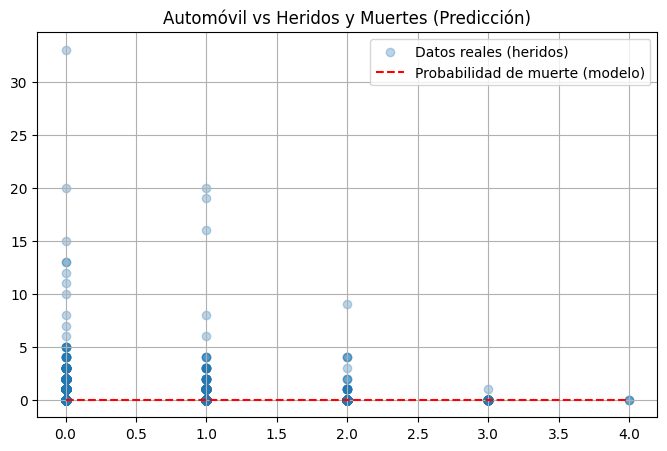

In [66]:
# Generar puntos para predecir
x_auto = np.linspace(x14.min(), x14.max(), 100)

# Crear entrada con todas las variables, excepto AUTOMOVIL (que varía)
X_pred = np.array([
    12 * np.ones(x_auto.shape),       # MES fijo
    18 * np.ones(x_auto.shape),      # Edad fija
    1 * np.ones(x_auto.shape),    # CONDHERIDO fijo
    x_auto,                          # AUTOMOVIL variable
]).T

# Predecir la probabilidad de muerte
y_pred = model.predict(X_pred)

# Graficar
plt.figure(figsize=(8, 5))
plt.scatter(x14, x6, label="Datos reales (heridos)", alpha=0.3)
plt.plot(x_auto, y_pred, 'r--', label='Probabilidad de muerte (modelo)')

plt.title('Automóvil vs Heridos y Muertes (Predicción)')
plt.legend()
plt.grid(True)
plt.show()

como se ve el modelo sigue una linea recta con las variables que se generan en los distintos puntos  aunque se ve que sigue un patron lineal

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


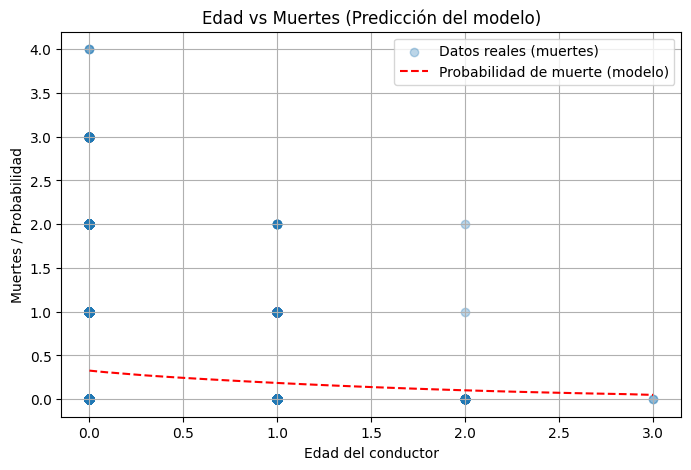

In [70]:
# Generar puntos para predecir
x5p = np.linspace(x5.min(), x5.max(), 100)

# Crear entrada con todas las variables, excepto AUTOMOVIL (que varía)
X_pred = np.array([
    12 * np.ones(x5p.shape),       # MES fijo
    x5p,
    1 * np.ones(x5p.shape),
    1 * np.ones(x5p.shape),
]).T

# Predecir la probabilidad de muerte
y_pred = model.predict(X_pred).flatten()

# Graficar
plt.figure(figsize=(8, 5))
plt.scatter(x5, x14, label="Datos reales (muertes)", alpha=0.3)
plt.plot(x5p, y_pred, 'r--', label='Probabilidad de muerte (modelo)')

plt.xlabel('Edad del conductor')
plt.ylabel('Muertes / Probabilidad')
plt.title('Edad vs Muertes (Predicción del modelo)')
plt.legend()
plt.grid(True)
plt.show()

En comparacion con el anterior se ve una pequeña desviacion de entre accidentes que involucren automoviles con respecto ala edad y se ve las desvicacion

# CONCLUSION
en este proyecto se mostro los diferentes metodos y usos de modelos matematicos que existen  y uno de los usos que se le puede dar a las redes neuronales para hacer modelos de prediccion basados en diferentes variables para dar a conocer una prediccion basado en distintos variables de la tabla